# *Лабораторная работа №1*

## Подготовка набора данных (Теоретическая часть)

При подготовке набора данных следует ориентироваться на поставленную задачу, так как именно от данного этапа зависит то, будут ли необходимые нам данные в итоговом наборе данных или нет. Вся дальнейшая обработка будет проводиться с целью разработки механизма определения стоимости автомобиля в зависимости от его характеристик.

Датасетом (набором данных), с которым будет вестись работа в данном лабораторном практикуме, является база данных о подержанных автомобилях, проданных в Германии в 2016 году, с сайта Kaggle.сom (в данный момент ссылка на страницу датасета на Kaggle не активна).                            
https://www.kaggle.com/orgesleka/used-cars-database/data

Библиотека warnings отвечает за то, какие предупреждения (warnings) о работе будут выводиться пользователю. FutureWarning - предупреждения о том, как изменится работа библиотек в будущих версиях. Поэтому такие предупреждения мы будем игнорировать. Чтобы включить режим игнорирования мы отбираем все предупреждения из категории FutureWarning и выбираем для них действия 'ignore'. Это делается вызовом функции simplefilter c задание двух атрибутов: действия action и категории предупреждений category.

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

Для работы с данными в python используется библиотека pandas. Подключим ее к проекту и для простоты обращения обозначим pd.

In [2]:
import pandas as pd

Загрузим наш набор данных для дальнейшей работы. %%capture используется для отключения уведомлений о ходе загрузки.

In [3]:
%%capture
!wget https://www.dropbox.com/s/wlbij79v3u4q2jy/autos.csv

Сохраним загруженный набор данных в виде dataframe - основной единицы при работе с библиотекой pandas. Такую возможность нам предоставляет команда read_csv, которая в качестве аргумента требует имя файла. Второй аргумент нам потребовалось использовать, так как наша база родом из Германии и содержит недоступные в базовой системе кодировки символы.

In [4]:
df = pd.read_csv('autos.csv', encoding='iso-8859-1')

*Примечание*: В рамках нашего курса мы ограничены достаточно скромным, по меркам больших данных, объемом файла. При работе с актуальными большими данными Вы можете столкнуться с тем, что файл полностью не может расположиться в оперативной памяти. В этом случае следует действовать по принципу «Разделяй и властвуй», то есть разбить базу данных на несколько файлов меньшего объема и обрабатывать их последовательно.

После выгрузки базы данных в память доступ к ней осуществляется через имя переменной. В частности, в рамках данной среды, при вводе имени осуществляется вывод на экран первых и последних строк базы и ее общий размер, в данном случае 371528 строк из 20-ти столбцов.

In [5]:
df

,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,2016-03-24 11:52:17,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,0,golf,150000,0,benzin,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,190,NaN,125000,5,diesel,audi,ja,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,163,grand,125000,8,diesel,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,75,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,69,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371523,2016-03-14 17:48:27,Suche_t4___vito_ab_6_sitze,privat,Angebot,2200,test,NaN,2005,NaN,0,NaN,20000,1,NaN,sonstige_autos,NaN,2016-03-14 00:00:00,0,39576,2016-04-06 00:46:52
371524,2016-03-05 19:56:21,Smart_smart_leistungssteigerung_100ps,privat,Angebot,1199,test,cabrio,2000,automatik,101,fortwo,125000,3,benzin,smart,nein,2016-03-05 00:00:00,0,26135,2016-03-11 18:17:12
371525,2016-03-19 18:57:12,Volkswagen_Multivan_T4_TDI_7DC_UY2,privat,Angebot,9200,test,bus,1996,manuell,102,transporter,150000,3,diesel,volkswagen,nein,2016-03-19 00:00:00,0,87439,2016-04-07 07:15:26
371526,2016-03-20 19:41:08,VW_Golf_Kombi_1_9l_TDI,privat,Angebot,3400,test,kombi,2002,manuell,100,golf,150000,6,diesel,volkswagen,NaN,2016-03-20 00:00:00,0,40764,2016-03-24 12:45:21


В качестве альтернативы можно использовать следующие команды:

In [6]:
df.head(10)

,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,2016-03-24 11:52:17,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,0,golf,150000,0,benzin,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,190,NaN,125000,5,diesel,audi,ja,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,163,grand,125000,8,diesel,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,75,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,69,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21
5,2016-04-04 17:36:23,BMW_316i___e36_Limousine___Bastlerfahrzeug__Ex...,privat,Angebot,650,test,limousine,1995,manuell,102,3er,150000,10,benzin,bmw,ja,2016-04-04 00:00:00,0,33775,2016-04-06 19:17:07
6,2016-04-01 20:48:51,Peugeot_206_CC_110_Platinum,privat,Angebot,2200,test,cabrio,2004,manuell,109,2_reihe,150000,8,benzin,peugeot,nein,2016-04-01 00:00:00,0,67112,2016-04-05 18:18:39
7,2016-03-21 18:54:38,VW_Derby_Bj_80__Scheunenfund,privat,Angebot,0,test,limousine,1980,manuell,50,andere,40000,7,benzin,volkswagen,nein,2016-03-21 00:00:00,0,19348,2016-03-25 16:47:58
8,2016-04-04 23:42:13,Ford_C___Max_Titanium_1_0_L_EcoBoost,privat,Angebot,14500,control,bus,2014,manuell,125,c_max,30000,8,benzin,ford,NaN,2016-04-04 00:00:00,0,94505,2016-04-04 23:42:13
9,2016-03-17 10:53:50,VW_Golf_4_5_tuerig_zu_verkaufen_mit_Anhaengerk...,privat,Angebot,999,test,kleinwagen,1998,manuell,101,golf,150000,0,NaN,volkswagen,NaN,2016-03-17 00:00:00,0,27472,2016-03-31 17:17:06


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371528 entries, 0 to 371527
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   dateCrawled          371528 non-null  object
 1   name                 371528 non-null  object
 2   seller               371528 non-null  object
 3   offerType            371528 non-null  object
 4   price                371528 non-null  int64 
 5   abtest               371528 non-null  object
 6   vehicleType          333659 non-null  object
 7   yearOfRegistration   371528 non-null  int64 
 8   gearbox              351319 non-null  object
 9   powerPS              371528 non-null  int64 
 10  model                351044 non-null  object
 11  kilometer            371528 non-null  int64 
 12  monthOfRegistration  371528 non-null  int64 
 13  fuelType             338142 non-null  object
 14  brand                371528 non-null  object
 15  notRepairedDamage    299468 non-nu

Теперь можно переходить непосредственно к анализу наших данных. Первым шагом в этом процессе должно стать определение количества уникальных значений в каждом столбце. Для начала рассмотрим первый столбец. Команда unique() генерирует список всех уникальных значений.

In [8]:
df['dateCrawled'].unique()

array(['2016-03-24 11:52:17', '2016-03-24 10:58:45',
       '2016-03-14 12:52:21', ..., '2016-03-14 17:48:27',
       '2016-03-19 18:57:12', '2016-03-07 19:39:19'], dtype=object)

Так как нам необходимо количество различных значений, то берем длину полученного списка.

In [9]:
len(df['dateCrawled'].unique())

280500

Проводим данную операцию для всех столбцов нашей базы данных.

In [10]:
names = list(df)
for name in names:
    print(name, len(df[name].unique()))

dateCrawled 280500
name 233531
seller 2
offerType 2
price 5597
abtest 2
vehicleType 9
yearOfRegistration 155
gearbox 3
powerPS 794
model 252
kilometer 13
monthOfRegistration 13
fuelType 8
brand 40
notRepairedDamage 3
dateCreated 114
nrOfPictures 1
postalCode 8150
lastSeen 182806


Полученный результат достаточно сложно анализировать, поэтому следует выровнять вывод столбцов на экран.

In [11]:
names = list(df)
for name in names:
    print("%20s%7d" % (name, len(df[name].unique())))

         dateCrawled 280500
                name 233531
              seller      2
           offerType      2
               price   5597
              abtest      2
         vehicleType      9
  yearOfRegistration    155
             gearbox      3
             powerPS    794
               model    252
           kilometer     13
 monthOfRegistration     13
            fuelType      8
               brand     40
   notRepairedDamage      3
         dateCreated    114
        nrOfPictures      1
          postalCode   8150
            lastSeen 182806


Столбцы с высокой кардинальностью (большим количеством уникальных значений) не несут практической пользы в рамках нашей задачи.

*Примечание*: Данная оговорка важна, так как, помимо задачи расчета стоимости подержанного автомобиля, данная база может обрабатываться кем-то в рамках исследования глобальных экономических процессов, тогда важным станет столбец со временем создания объявления, что позволит делать выводы о текущей экономической ситуации в стране в зависимости от запрошенной владельцем стоимости в конкретный момент времени, или столбец с почтовыми индексами, для анализа зависимости цен от географического расположения участника сделки.

Исходя из специфики нашего исследования, мы можем смело избавиться от столбцов с датой, датой последнего просмотра объявления, почтовым индексом и именем объявления, так как, исходя из анализа кардинальности, оно не несет полезной информации, а лишь является агрегацией нескольких других полей.

Хотя столбец цены тоже обладает высокой кардинальностью, его следует оставить не только из-за того, что он является ключевым для нашего исследования, но и, исходя из вполне обоснованного предположения, что многообразие цен является закономерным и обыденным.

In [12]:
del df["dateCrawled"]
del df["name"]
del df["postalCode"]
del df["lastSeen"]

Теперь следует рассмотреть какие еще поля можно исключить из рассмотрения, как неактуальные для нашей задачи. Тип продавца, тип сделки, столбец «abtest», описание которого отсутствует даже на сайте с набором данных, дата создания объявления и количество изображений в объявлении на мой субъективный взгляд являются малозначимыми для нашей задачи. Вы можете думать иначе и, возможно, захотите их оставить. Будет интересно узнать Ваше видение ситуации. Кроме того, я считаю, что следует избавиться от месяца регистрации ТС, из-за некой избыточности этих данных.

В рамках полноценного исследования следует подтверждать каждое действие подобного рода вычислением различных регрессионных показателей.

In [13]:
del df["seller"]
del df["offerType"]
del df["abtest"]
del df["monthOfRegistration"]
del df["dateCreated"]
del df["nrOfPictures"]

In [14]:
names = list(df)
for name in names:
    print("%20s%7d" % (name, len(df[name].unique())))

               price   5597
         vehicleType      9
  yearOfRegistration    155
             gearbox      3
             powerPS    794
               model    252
           kilometer     13
            fuelType      8
               brand     40
   notRepairedDamage      3


Теперь необходимо определить в каких столбцах присутствуют поврежденные (неполные) данные. Для столбцов с присутствующими NULL-элементами произведем подсчет количества этих элементов.

In [15]:
df.isnull().any()

,0
price,False
vehicleType,True
yearOfRegistration,False
gearbox,True
powerPS,False
model,True
kilometer,False
fuelType,True
brand,False
notRepairedDamage,True


In [16]:
sum(pd.isnull(df['vehicleType']))

37869

In [17]:
sum(pd.isnull(df['gearbox']))

20209

In [18]:
sum(pd.isnull(df['model']))

20484

In [19]:
sum(pd.isnull(df['fuelType']))

33386

In [20]:
sum(pd.isnull(df['notRepairedDamage']))

72060

Несмотря на то, что столбец с информацией о наличии восстановительных работ очень важен при формировании цены, мы не можем удалить из базы все строки с пропущенным данным параметром, так как это моментально приведет к потере 20% накопленной информации.


Отсутствие в части объявлении информации о типе кузова автомобиля не является критическим, так как может быть восстановлен по марке и модели. Следовательно, необходимо сосредоточиться на оставшихся трех столбцах.

Последовательно производится удаление поврежденных данных из столбцов с данными о коробке передач, мощности двигателя и модели. Если вернуться к подсчету отсутствующих полей в трех столбцах и сравнить их общее количество с количеством фактически удаленных данных получим расхождение примерно в двадцать тысяч записей, что свидетельствует о пересечении данных множеств.

In [21]:
len(df.index)

371528

In [22]:
df = df.drop(df[pd.isnull(df['gearbox'])].index)

In [23]:
len(df.index)

351319

In [24]:
df = df.drop(df[pd.isnull(df['model'])].index)

In [25]:
len(df.index)

335068

In [26]:
df = df.drop(df[pd.isnull(df['fuelType'])].index)

In [27]:
len(df.index)

315097

In [28]:
371528 - 315097

56431

In [29]:
20209 + 20484 + 33386

74079

Так как удаление 56 тысяч записей не многим лучше удаления 72 тысяч, удалим из базы лишь те записи, в которых отсутствуют все три перечисленных поля одновременно, а в остальных случаях впоследствии воспользуемся какими-либо методами восстановления данных, например, деревом решений.

Восстановим базу до состояния перед началом удаления строк.

In [30]:
df = pd.read_csv('autos.csv', encoding='iso-8859-1')
del df["dateCrawled"]
del df["name"]
del df["postalCode"]
del df["lastSeen"]
del df["seller"]
del df["offerType"]
del df["abtest"]
del df["monthOfRegistration"]
del df["dateCreated"]
del df["nrOfPictures"]

Проверим состояние базы и проведем удаление.

In [31]:
len(df.index)

371528

In [32]:
df = df.drop(df[pd.isnull(df['gearbox']) & pd.isnull(df['model']) & pd.isnull(df['fuelType'])].index)

In [33]:
len(df.index)

368533

По итогу получили удаление приблизительно трех тысяч записей, что не является критичным, так как составляет меньше 1% от исходного набора.

Для оставшихся трех числовых столбцов построим гистограммы, чтобы убедиться в целостности и правильности данных.

array([[<Axes: title={'center': 'kilometer'}>]], dtype=object)

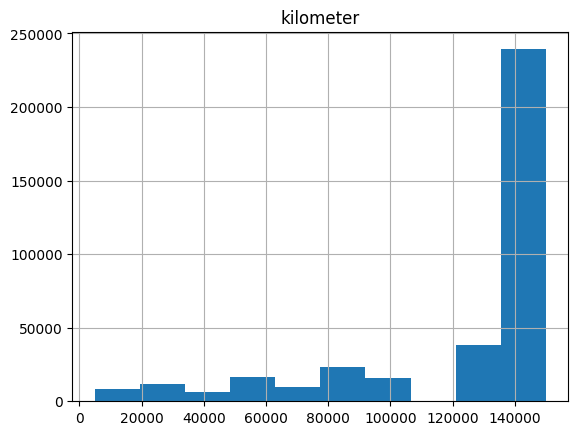

In [34]:
df.hist(["kilometer"])

Как прекрасно видно из гистограммы, никаких патологий в столбце с пробегом не наблюдается.

array([[<Axes: title={'center': 'yearOfRegistration'}>]], dtype=object)

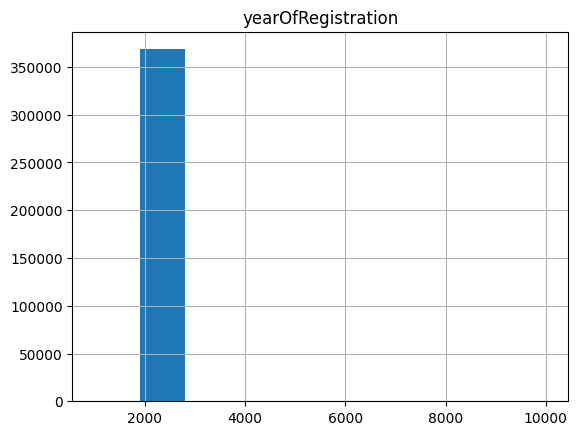

In [35]:
df.hist(["yearOfRegistration"])

А вот на данных о годе регистрации ТС картина не столь хороша. Как можно видеть из гистограммы, основной объем зарегистрированных автомобилей приходится на стык первого и второго тысячелетия, что, в целом, соответствует действительности. Что же не так? Растянутая ось абсцисс свидетельствует о том, что в нашей базе есть записи, в которых год регистрации превышает 9000 год нашей эры. Разберемся с этим более подробно.

При выводе гистограммы для временного периода с 1950-го года по 2020-ый получаем вполне закономерную картину. Автомобилей старых лет на рынке все меньше из-за банального износа, а автомобили последнего десятилетия продаются менее активно, так как автомобиль возрастом до пяти лет, в принципе, считается новым и хозяева редко решают расстаться с ним.

array([[<Axes: title={'center': 'yearOfRegistration'}>]], dtype=object)

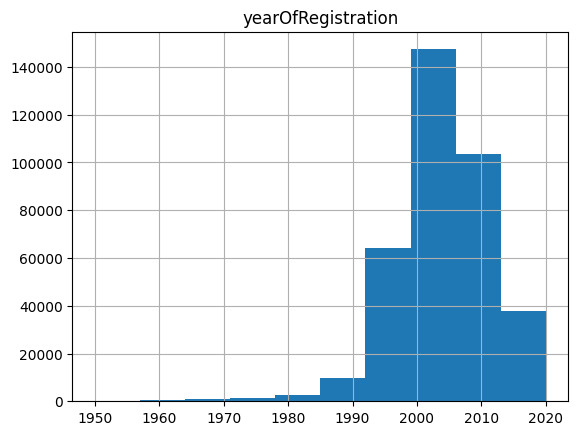

In [36]:
df.hist(["yearOfRegistration"], range = [1950, 2020])

При рассмотрении промежутка до 1950-го года получаем, что кто-то продает автомобили, произведенные в начале второго тысячелетия. Конечно, может быть это какие-то экипажи, мощностью в 6 лошадиных сил или колесницы в 2 л.с., но, в рамках данной работы, их стоит исключить, так как даже в рамках пика около 1950 объем этих объявлений не превышает 200.

array([[<Axes: title={'center': 'yearOfRegistration'}>]], dtype=object)

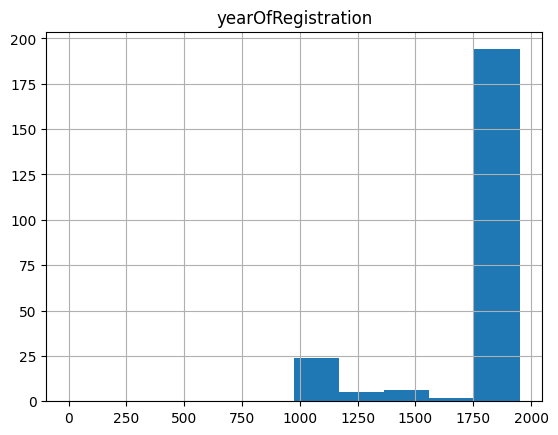

In [37]:
df.hist(["yearOfRegistration"], range = [0, 1950])

Так же стоит избавиться от ~100 объявлений о продаже средств передвижения путешественников во времени, прибывших к нам из далекого и не очень будущего.

array([[<Axes: title={'center': 'yearOfRegistration'}>]], dtype=object)

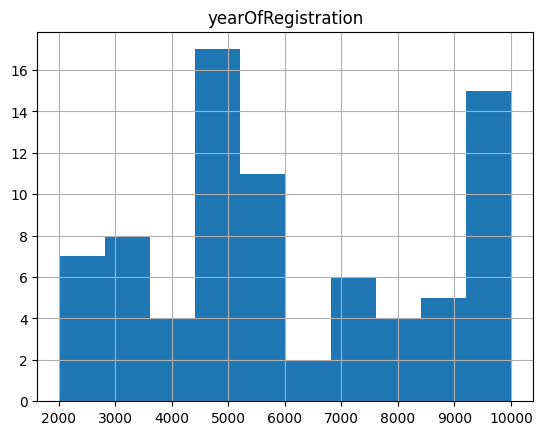

In [38]:
df.hist(["yearOfRegistration"], range = [2020, 10000])

In [39]:
df= df[(df['yearOfRegistration'] < 2020) & (df['yearOfRegistration'] > 1950)]

array([[<Axes: title={'center': 'yearOfRegistration'}>]], dtype=object)

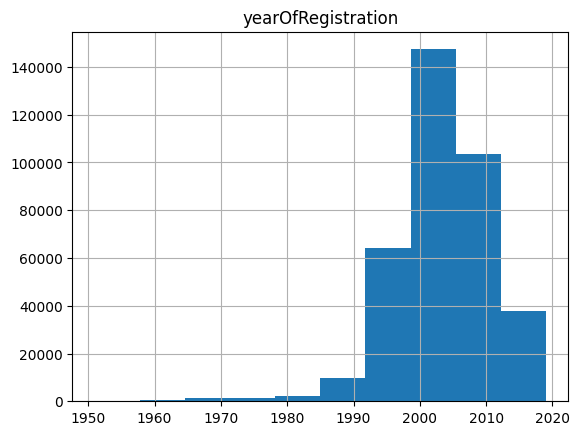

In [40]:
df.hist(["yearOfRegistration"])

На этом работу со столбцом с годом регистрации можно завершить.

В рамках рассмотрения столбца с мощностью двигателя продаваемого ТС получаем уже знакомую картину.

array([[<Axes: title={'center': 'powerPS'}>]], dtype=object)

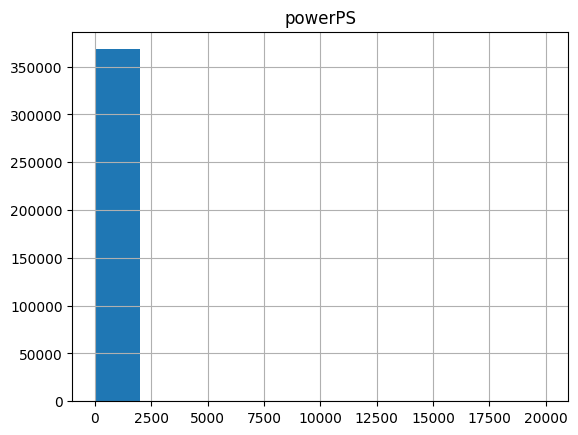

In [41]:
df.hist(["powerPS"])

Исходя из предположения, что рассматривать объявления о продаже машин со снятым двигателем, имеющих 0 лошадиных сил, и о продаже танков, самолетов и кораблей с силовыми установками более 2000 л.с., мы не будем, удаляем записи из данного диапазона.

array([[<Axes: title={'center': 'powerPS'}>]], dtype=object)

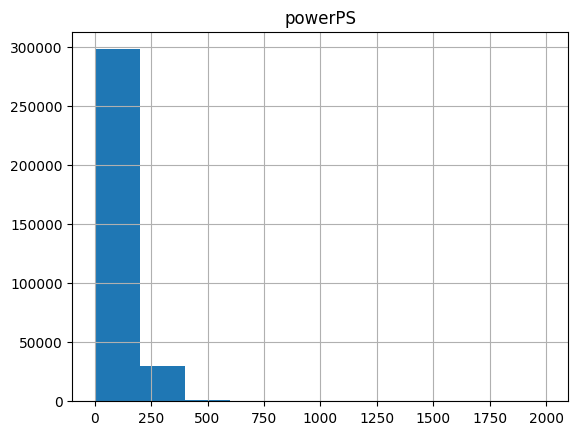

In [42]:
df = df[(df['powerPS'] < 2000) & ~(df['powerPS'] == 0)]
df.hist(["powerPS"])

Далее следует сомнительный, даже с моей точки зрения, шаг. Но, учитывая общий объем объявлений с мощностью в диапазоне от 600 до 2000 л.с. от них тоже можно избавиться. Вызвано это особенностями обработки информации с помощью интеллектуальных моделей, с чем мы столкнемся в дальнейшем.

array([[<Axes: title={'center': 'powerPS'}>]], dtype=object)

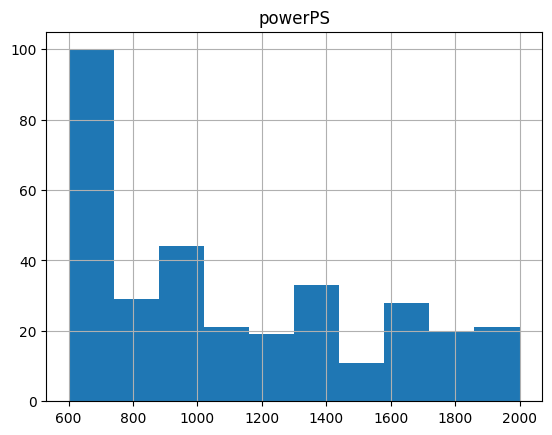

In [43]:
df.hist(["powerPS"], range = [600, 2000])

In [44]:
len(df.index)

329983

In [45]:
df = df[df['powerPS'] < 600]

In [46]:
len(df.index)

329657

array([[<Axes: title={'center': 'price'}>]], dtype=object)

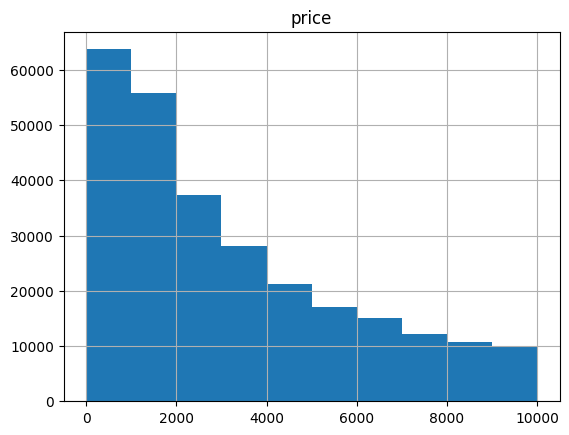

In [47]:
df.hist(["price"], range = [0, 10000])

В результате нашей предварительной обработки данных мы получили базу с общим объемом записей около 330 тысяч. Таким образом, удалению подверглось около сорока тысяч записей, что в процентном выражении составляет около 11% от общего объема базы.  

Подключим все необходимые для дальнейшей работы библиотеки.

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import copy

from sklearn import ensemble
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split


Записываем ее в датафрейм и проверим столбцы на наличие пустых значений.

Воспользуемся самым ленивым способом восстановления данных и очистим все столбцы от пустых значений, чтобы работать с исключительно неповрежденными записями.

In [49]:
df = df.drop(df[pd.isnull(df['vehicleType'])].index)
df = df.drop(df[pd.isnull(df['gearbox'])].index)
df = df.drop(df[pd.isnull(df['model'])].index)
df = df.drop(df[pd.isnull(df['fuelType'])].index)
df = df.drop(df[pd.isnull(df['notRepairedDamage'])].index)

Проверим, что у нас не осталось записей с пустыми значениями.

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250919 entries, 3 to 371527
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   price               250919 non-null  int64 
 1   vehicleType         250919 non-null  object
 2   yearOfRegistration  250919 non-null  int64 
 3   gearbox             250919 non-null  object
 4   powerPS             250919 non-null  int64 
 5   model               250919 non-null  object
 6   kilometer           250919 non-null  int64 
 7   fuelType            250919 non-null  object
 8   brand               250919 non-null  object
 9   notRepairedDamage   250919 non-null  object
dtypes: int64(4), object(6)
memory usage: 21.1+ MB


В нашем наборе данных достаточно большое количество полей типа object. Для того, чтобы с ними можно было работать, необходимо провести факторизацию, но сначала рассмотрим эти значения.

In [51]:
df['vehicleType'].unique()

array(['kleinwagen', 'limousine', 'cabrio', 'kombi', 'suv', 'bus',
       'coupe', 'andere'], dtype=object)

In [52]:
df['gearbox'].unique()

array(['manuell', 'automatik'], dtype=object)

In [53]:
df['model'].unique()

array(['golf', 'fabia', '3er', '2_reihe', 'andere', '3_reihe', 'passat',
       'navara', 'twingo', 'c_max', 'a_klasse', 'scirocco', '5er',
       'arosa', 'civic', 'transporter', 'punto', 'e_klasse', 'one',
       'clio', '1er', 'b_klasse', 'fortwo', 'a8', 'jetta', 'fiesta',
       'c_klasse', 'micra', 'vito', 'sprinter', '156', 'escort',
       'forester', 'scenic', 'a1', 'focus', 'tt', 'astra', 'a6', 'jazz',
       'polo', 'slk', '7er', 'combo', '80', '147', 'glk', 'meriva',
       'z_reihe', 'ibiza', 'mustang', 'eos', 'a4', 'touran', 'getz',
       'insignia', 'megane', 'a3', 'lupo', 'r19', 'colt', 'corsa',
       'vectra', 'berlingo', 'm_klasse', 'tiguan', '6_reihe', 'c4',
       'panda', 'up', 'i_reihe', 'ceed', 'kangoo', '5_reihe', 'yeti',
       'octavia', 'zafira', 'mii', 'rx_reihe', 'mondeo', '6er', 'fox',
       'matiz', 'beetle', 'rio', 'touareg', 'logan', 'omega', 'cuore',
       's_max', 'modus', 'a2', 'x_reihe', 'a5', 'galaxy', 'c3', 'viano',
       's_klasse', 'sharan',

In [54]:
df['fuelType'].unique()

array(['benzin', 'diesel', 'lpg', 'andere', 'hybrid', 'cng', 'elektro'],
      dtype=object)

In [55]:
df['notRepairedDamage'].unique()

array(['nein', 'ja'], dtype=object)

Для поля, которое нас интересует больше всего проверим соотношение количества записей, относящихся к разным классам.

Проведем факторизацию и проверим результат ее исполнения.

In [56]:
names = ['vehicleType', 'gearbox', 'model', 'fuelType', 'brand', 'notRepairedDamage']
for name in names:
    df[name] = pd.factorize(df[name])[0]
df.head()

,price,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,fuelType,brand,notRepairedDamage
3,1500,0,2001,0,75,0,150000,0,0,0
4,3600,0,2008,0,69,1,90000,1,1,0
5,650,1,1995,0,102,2,150000,0,2,1
6,2200,2,2004,0,109,3,150000,0,3,0
7,0,1,1980,0,50,4,40000,0,0,0


Как мы можем видеть, в результате удаления части значений из базы данных, произошло нарушение следования индексов. В рамках нашей задачи данный аспект не критичен, но все же произведем сброс индексации.

In [57]:
df.to_csv('autos_mod.csv', encoding='iso-8859-1')

Сохраним итоговый набор данных для использования его в дальнейшем.

In [58]:
df = df.reset_index(drop=True)
df.head()

,price,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,fuelType,brand,notRepairedDamage
0,1500,0,2001,0,75,0,150000,0,0,0
1,3600,0,2008,0,69,1,90000,1,1,0
2,650,1,1995,0,102,2,150000,0,2,1
3,2200,2,2004,0,109,3,150000,0,3,0
4,0,1,1980,0,50,4,40000,0,0,0


Разобьем весь наш набора данных на тренировочный и тестовый наборы данных.

In [59]:
values = df['price']
points = df.drop(['price'], axis=1)
train_points, test_points, train_values, test_values = train_test_split(points, values, test_size = 0.2)

Создадим достаточно простую модель из 10 решающих деревьев и оценим точность ее работы.

In [60]:
rf_model = ensemble.RandomForestRegressor(n_estimators=10)
rf_model.fit(train_points, train_values)
test_predict_rf = rf_model.predict(test_points)
print(mean_absolute_error(test_values, test_predict_rf))

7479.12222556928


Средняя абсолютная ошибка в размере 7.5 тысяч долларов - безусловно не то, что хочет получить пользователь подобной системы, но в рамках данной лабораторной задача состоит только в обеспечении формальной возможности построения модели предсказания, а настройка гиперпараметров алгоритмов предсказания будет подробнее разбираться в последующих работах.

Три момента, которые необходимо проверить в конце предобработки набора данных:
1. Размер датасета для всех полей совпадает с количеством непустых значений.
2. Проведена факторизация всех полей, по которым строится модель принятия решений (т.е. отсутствуют поля типа object).
3. На основе датасета возможно построение модели (т.е. отсутствуют ошибки построения).

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250919 entries, 0 to 250918
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   price               250919 non-null  int64
 1   vehicleType         250919 non-null  int64
 2   yearOfRegistration  250919 non-null  int64
 3   gearbox             250919 non-null  int64
 4   powerPS             250919 non-null  int64
 5   model               250919 non-null  int64
 6   kilometer           250919 non-null  int64
 7   fuelType            250919 non-null  int64
 8   brand               250919 non-null  int64
 9   notRepairedDamage   250919 non-null  int64
dtypes: int64(10)
memory usage: 19.1 MB


In [63]:
values = df['price']
points = df.drop(['price'], axis=1)
train_points, test_points, train_values, test_values = train_test_split(points, values, test_size = 0.2, random_state = 42)

rf_model = ensemble.RandomForestRegressor(n_estimators=10, random_state = 42)
rf_model.fit(train_points, train_values)
test_predict_rf = rf_model.predict(test_points)
print(mean_absolute_error(test_values, test_predict_rf))

4845.857678574133


## Подготовка набора данных (Практическая часть)

Вашим заданием в данной лабораторной будет подготовка набора данных к дальнейшему построению регрессионной модели для определения стоимости жилья. Для повышения предсказуемости получения результата используйте random_state, равный Вашему порядковому номеру в группе. Данное задание основано на данном датасете с kaggle (https://www.kaggle.com/new-york-city/nyc-property-sales).

В качестве результата выполнения должен выступать **датасет** размером не менее 50000 записей, не содержащий пустых полей и допускающий построение регрессионной модели на базе случайного леса (в качестве образца подтверждения достижения цели можно использовать последние две ячейки с кодом из теоретической части), а также **отчет** о проделанных действиях. Результирующий датасет будет использоваться в четвертой лабораторной работе.

In [ ]:
%%capture
!wget https://www.dropbox.com/s/0un1sdvifenp2ir/nyc-rolling-sales.csv